# Rule-based vs Optimised HVAC Control
Comparison of energy use and thermal comfort.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
from simulate import run_baseline_simulation
from optimise import run_optimised_simulation

print("Running baseline (rule-based)...")
df_base = run_baseline_simulation(n_steps=96)   # 4 days

print("Running optimised controller (this takes 1–2 minutes)...")
df_opt = run_optimised_simulation(n_steps=96, horizon=6)

print("\n=== RESULTS ===")
print(f"Baseline energy:   {df_base['energy_kWh'].sum():.1f} kWh")
print(f"Optimised energy:  {df_opt['energy_kWh'].sum():.1f} kWh")
print(f"Energy saving:     {df_base['energy_kWh'].sum() - df_opt['energy_kWh'].sum():.1f} kWh")
print()
print(f"Baseline T range:  {df_base['T_in'].min():.1f} – {df_base['T_in'].max():.1f} °C")
print(f"Optimised T range: {df_opt['T_in'].min():.1f} – {df_opt['T_in'].max():.1f} °C")

Running baseline (rule-based)...
Running optimised controller (this takes 1–2 minutes)...

=== RESULTS ===
Baseline energy:   66.0 kWh
Optimised energy:  74.9 kWh
Energy saving:     -8.9 kWh

Baseline T range:  17.4 – 25.5 °C
Optimised T range: 19.9 – 24.1 °C


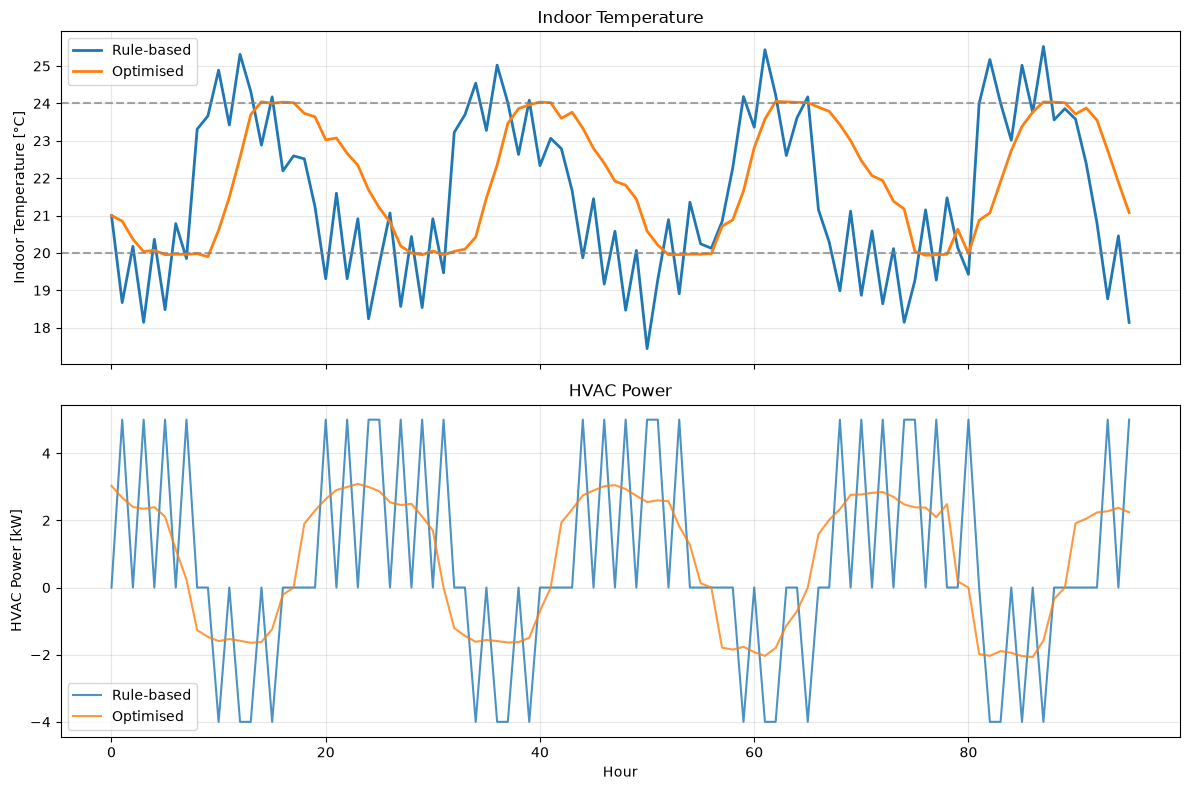

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Temperature
axes[0].plot(df_base["hour"], df_base["T_in"], label="Rule-based", linewidth=2)
axes[0].plot(df_opt["hour"], df_opt["T_in"], label="Optimised", linewidth=2)
axes[0].axhline(20, color="gray", linestyle="--", alpha=0.7)
axes[0].axhline(24, color="gray", linestyle="--", alpha=0.7)
axes[0].set_ylabel("Indoor Temperature [°C]")
axes[0].legend()
axes[0].set_title("Indoor Temperature")
axes[0].grid(True, alpha=0.3)

# HVAC power
axes[1].plot(df_base["hour"], df_base["Q_HVAC"]/1000, label="Rule-based", alpha=0.8)
axes[1].plot(df_opt["hour"], df_opt["Q_HVAC"]/1000, label="Optimised", alpha=0.8)
axes[1].set_ylabel("HVAC Power [kW]")
axes[1].set_xlabel("Hour")
axes[1].legend()
axes[1].set_title("HVAC Power")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

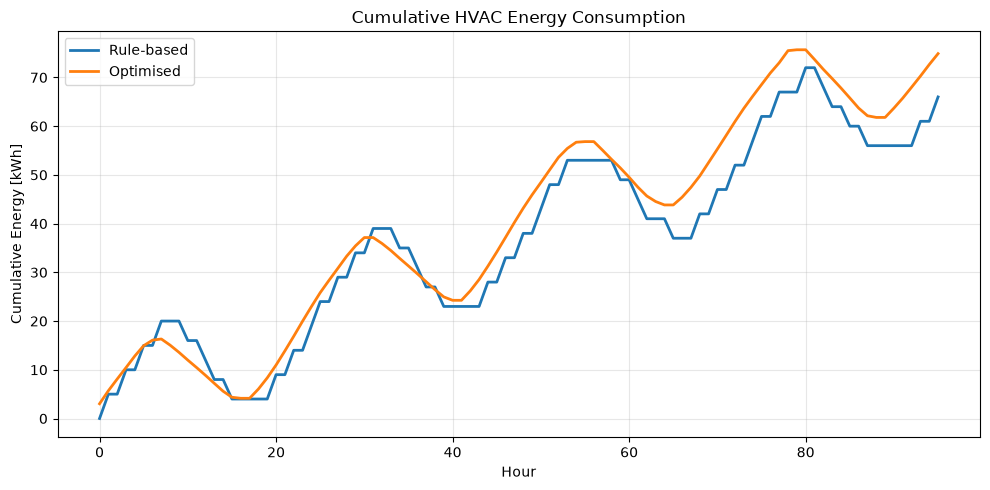

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(df_base["hour"], df_base["energy_kWh"].cumsum(), label="Rule-based", linewidth=2)
plt.plot(df_opt["hour"], df_opt["energy_kWh"].cumsum(), label="Optimised", linewidth=2)
plt.xlabel("Hour")
plt.ylabel("Cumulative Energy [kWh]")
plt.title("Cumulative HVAC Energy Consumption")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()